In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 加载数据
# 假设你的 RUTH 数据路径
#ruth_path = '../data/processed/his_portion_50pc.h5'
# RUTH早/晚高峰数据
ruth_morning_speed_path = '../data/processed/his_50pc_1min_morning_speed.h5'
ruth_morning_flow_path = '../data/processed/his_50pc_1min_morning_flow.h5'
ruth_evening_speed_path = '../data/processed/his_50pc_1min_evening_speed.h5'
ruth_evening_flow_path = '../data/processed/his_50pc_1min_evening_flow.h5'
# 假设 LargeST 的数据路径 (例如 PeMS04 或 PeMS08)
largest_path = '/users/jliu312/RuthST/LargeST/data/ca/ca_his_2021.h5' # 请根据实际路径修改

#df_ruth = pd.read_hdf(ruth_path)
df_ruth_morning_speed = pd.read_hdf(ruth_morning_speed_path)
df_ruth_evening_speed = pd.read_hdf(ruth_evening_speed_path)
df_ruth_morning_flow = pd.read_hdf(ruth_morning_flow_path)
df_ruth_evening_flow = pd.read_hdf(ruth_evening_flow_path)
df_largest = pd.read_hdf(largest_path) # 如果有的话

#print(f"RUTH 数据形状: {df_ruth.shape}") # (时间步, 29735)
print(f"RUTH 早高峰 速度 数据形状: {df_ruth_morning_speed.shape}")
print(f"RUTH 早高峰 流量 数据形状: {df_ruth_morning_flow.shape}")
print(f"RUTH 晚高峰 速度 数据形状: {df_ruth_evening_speed.shape}")
print(f"RUTH 晚高峰 流量 数据形状: {df_ruth_evening_flow.shape}")
print(f"LargeST 数据形状: {df_largest.shape}") 

RUTH 早高峰 速度 数据形状: (158, 2453)
RUTH 早高峰 流量 数据形状: (158, 2453)
RUTH 晚高峰 速度 数据形状: (150, 2453)
RUTH 晚高峰 流量 数据形状: (150, 2453)
LargeST 数据形状: (35040, 8600)


In [21]:
# 2. 绘制时间序列对比图 (选几个有代表性的路段)
def plot_time_series(df, title, num_roads=5):
    plt.figure(figsize=(15, 5))
    # 随机选几个有速度数据的路段（避开全为0的）
    active_roads = df.columns[(df.mean() > 5)][:num_roads]
    for road in active_roads:
        plt.plot(df.index, df[road], label=f'Road {road}')
    
    plt.title(f"{title} - Speed Time Series")
    plt.xlabel("Time")
    plt.ylabel("Speed (mph)")
    plt.legend()
    plt.show()

In [22]:
def plot_time_series_segmented(df, title, num_roads=5):
    # 1. 定义切片跨度 (150分钟 = 2.5小时)
    slice_mins = 150
    freq = f'{slice_mins}min'
    
    # 2. 按照 2.5 小时进行分组循环
    # pd.Grouper 会自动处理全天的时间切分
    for timestamp, group in df.groupby(pd.Grouper(freq=freq)):
        
        # 过滤掉完全没数据的时段（比如凌晨或断档）
        if group.empty or (group.max().max() == 0):
            continue
            
        plt.figure(figsize=(15, 5))
        
        # 3. 在当前切片中选出最活跃的路段（这样每张图的路段可能不同，但保证有波动）
        active_roads = group.columns[(group.mean() > 5)][:num_roads]
        
        if len(active_roads) == 0:
            plt.close()
            continue

        for road in active_roads:
            # 加上 marker='o'，因为 2.5 小时内采样点少，有点看更清楚
            plt.plot(group.index, group[road], label=f'Road {road}', marker='o', markersize=3)
        
        # 4. 动态设置标题，显示当前切片的时间段
        start_str = timestamp.strftime('%Y-%m-%d %H:%M')
        end_str = (timestamp + pd.Timedelta(minutes=slice_mins)).strftime('%H:%M')
        
        plt.title(f"{title} | {start_str} - {end_str}")
        plt.xlabel("Time")
        plt.ylabel("Speed (mph)")
        plt.grid(True, alpha=0.3)
        plt.legend(loc='upper right', fontsize='small')
        plt.show()

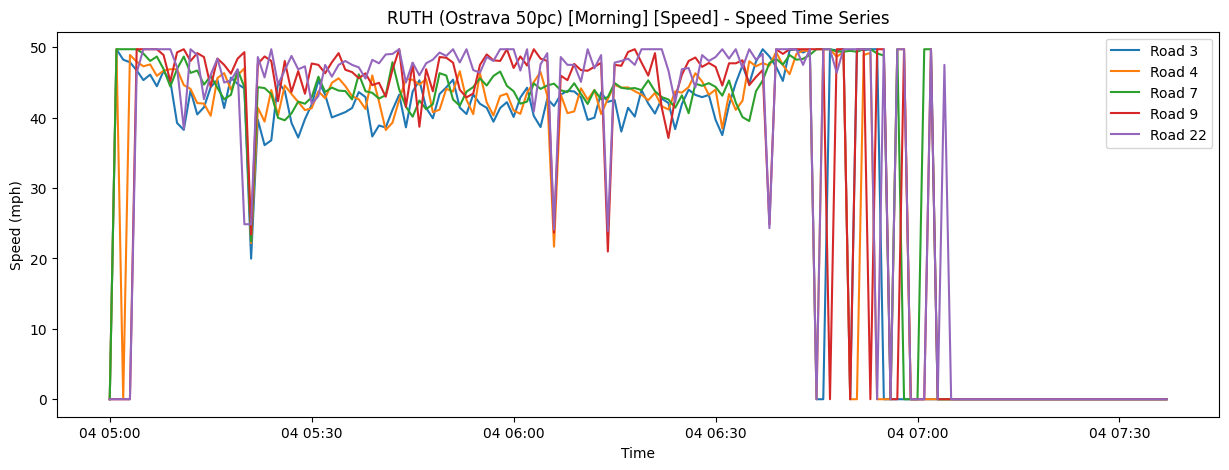

In [23]:
plot_time_series(df_ruth_morning_speed, "RUTH (Ostrava 50pc) [Morning] [Speed]")

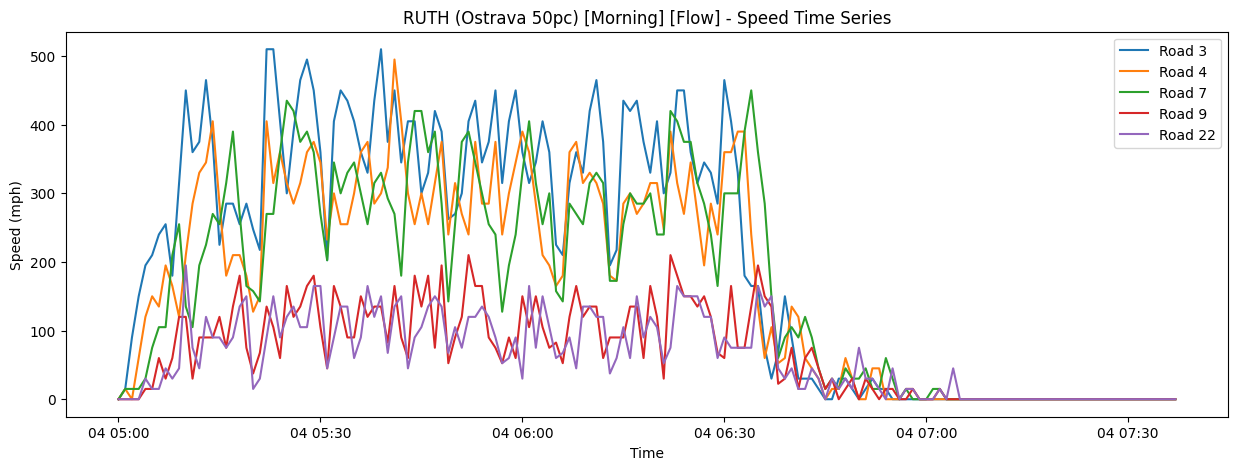

In [24]:
plot_time_series(df_ruth_morning_flow * 15, "RUTH (Ostrava 50pc) [Morning] [Flow]")

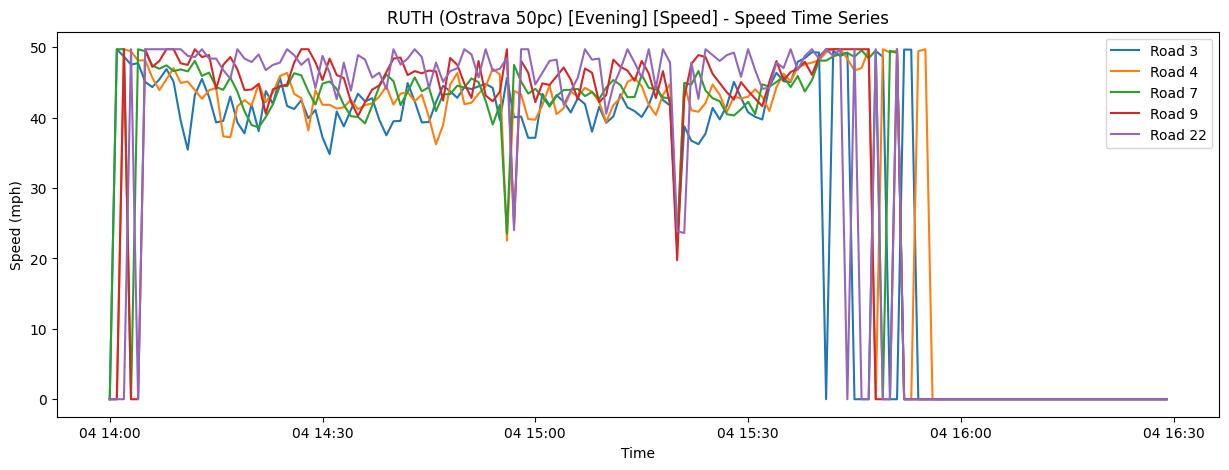

In [25]:
plot_time_series(df_ruth_evening_speed, "RUTH (Ostrava 50pc) [Evening] [Speed]")

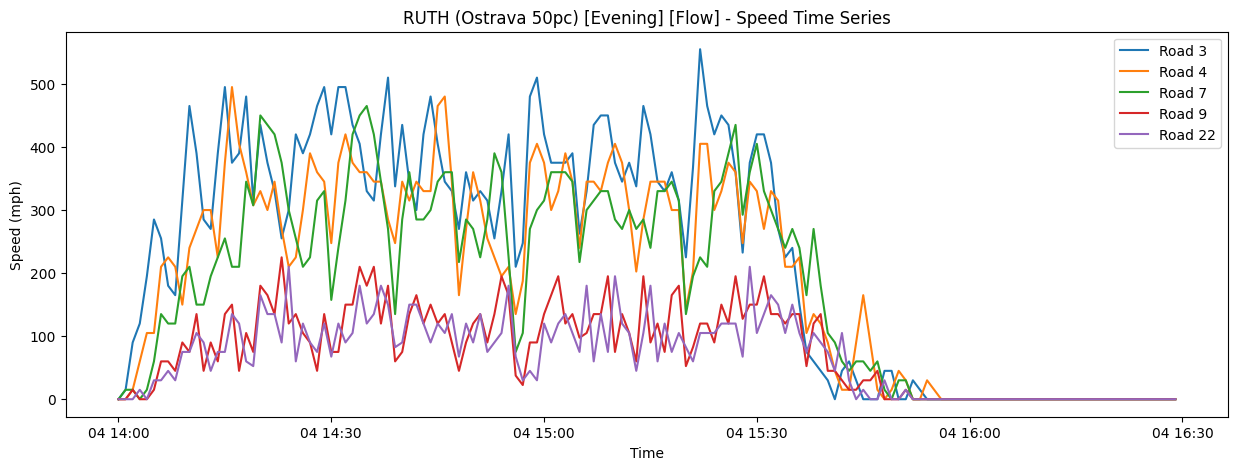

In [26]:
plot_time_series(df_ruth_evening_flow*15, "RUTH (Ostrava 50pc) [Evening] [Flow]")

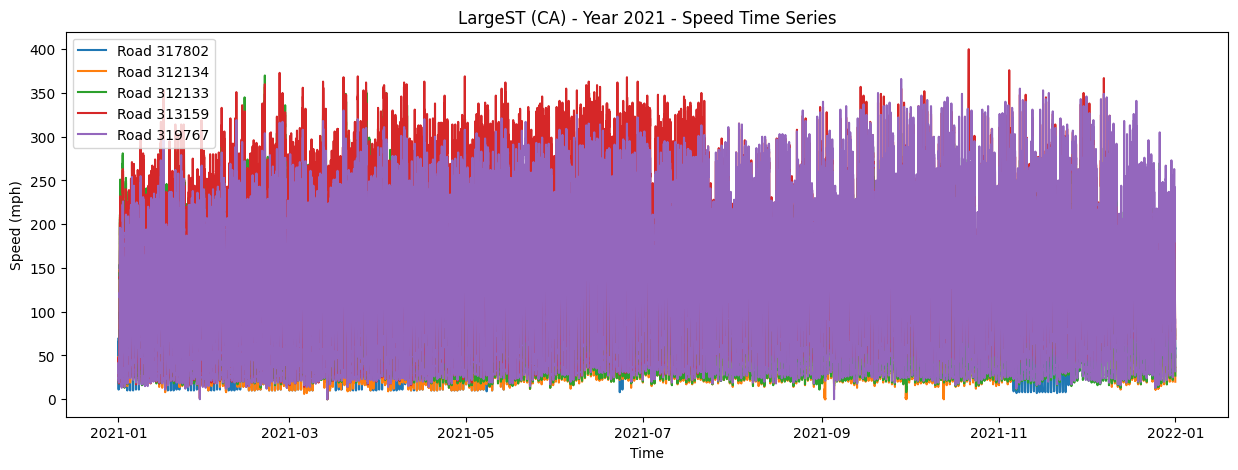

In [28]:
plot_time_series(df_largest, "LargeST (CA) - Year 2021")

In [41]:
# 3. 绘制时空热力图 (Heatmap)
# 横轴是时间，纵轴是路段 ID
def plot_heatmap(df, title, max_roads=100, max_steps=150):
    plt.figure(figsize=(12, 8))
    # 截取前 100 条路的前 200 个时间步，否则图太大画不出来
    subset = df.iloc[:max_steps, :max_roads].T
    sns.heatmap(subset, cmap='RdYlGn', cbar_kws={'label': 'Speed (mph)'})
    plt.title(f"{title} - Spatio-Temporal Heatmap")
    plt.xlabel("Time Steps")
    plt.ylabel("Road ID (ID2)")
    plt.show()

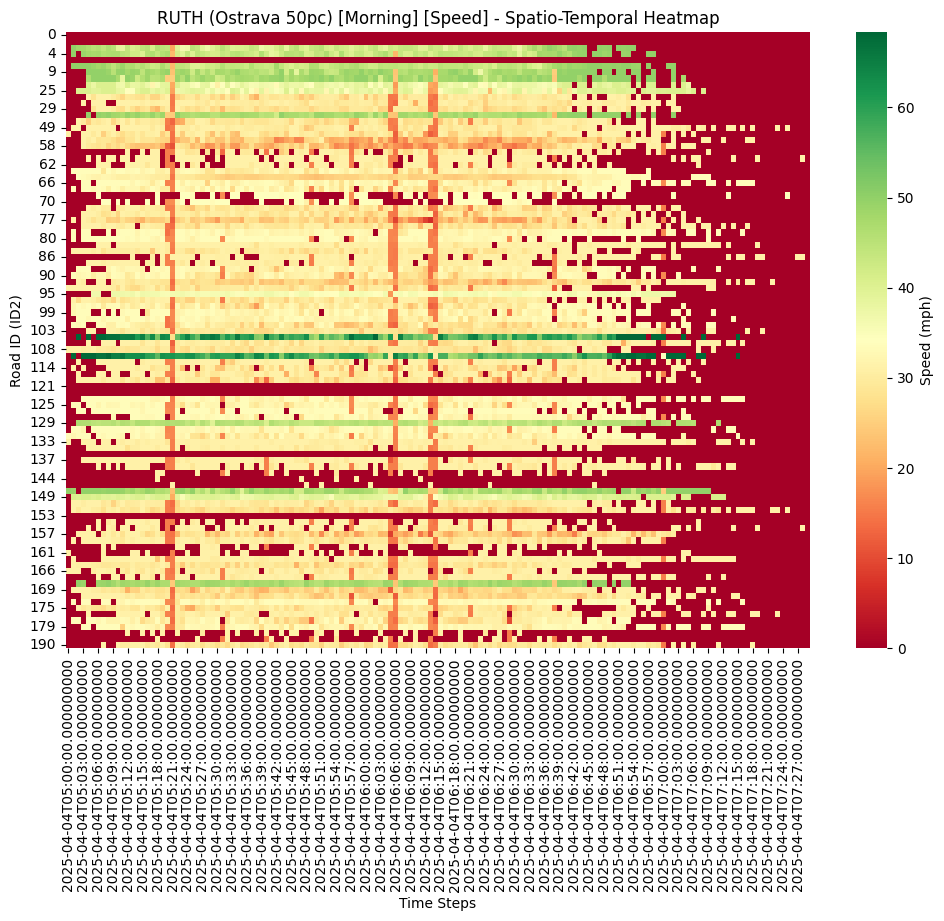

In [42]:
plot_heatmap(df_ruth_morning_speed, "RUTH (Ostrava 50pc) [Morning] [Speed]")

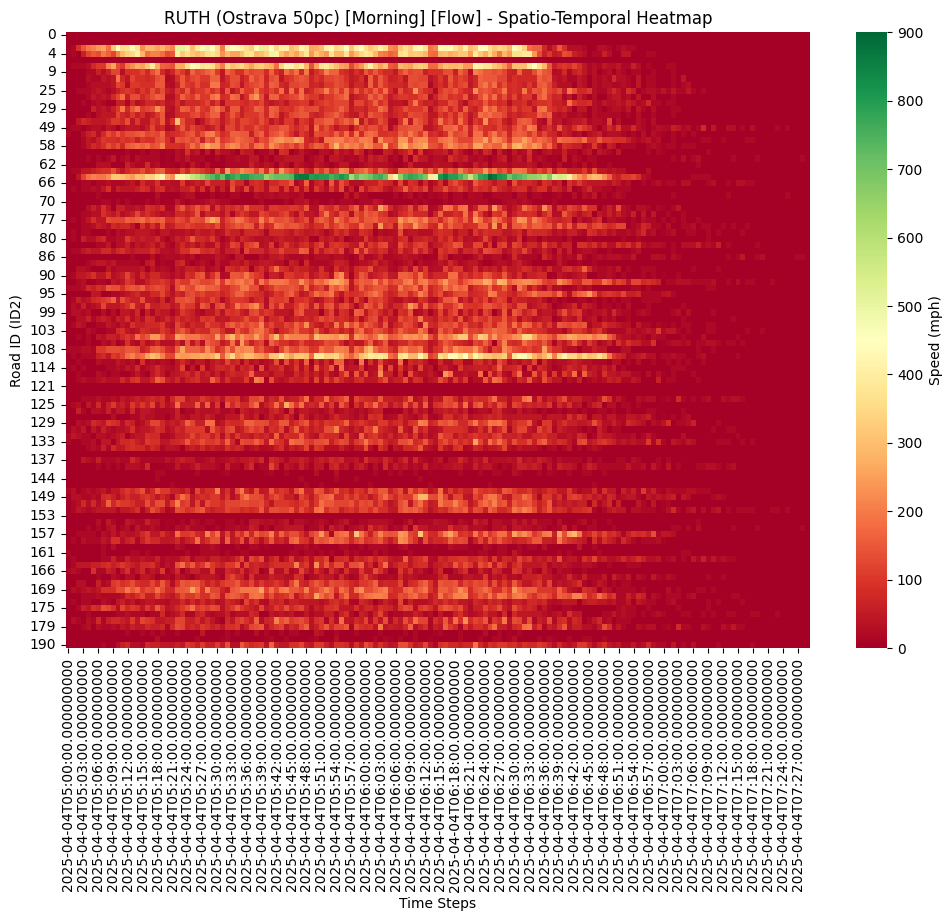

In [43]:
plot_heatmap(df_ruth_morning_flow * 15, "RUTH (Ostrava 50pc) [Morning] [Flow]")

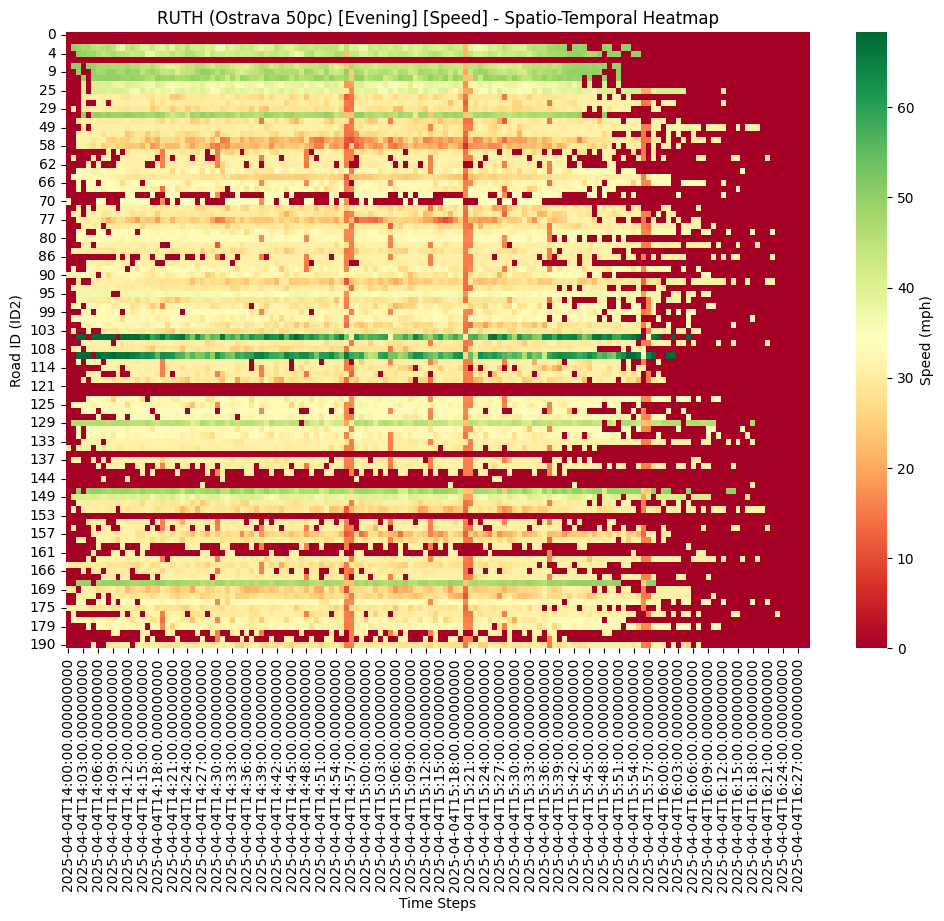

In [44]:
plot_heatmap(df_ruth_evening_speed, "RUTH (Ostrava 50pc) [Evening] [Speed]")

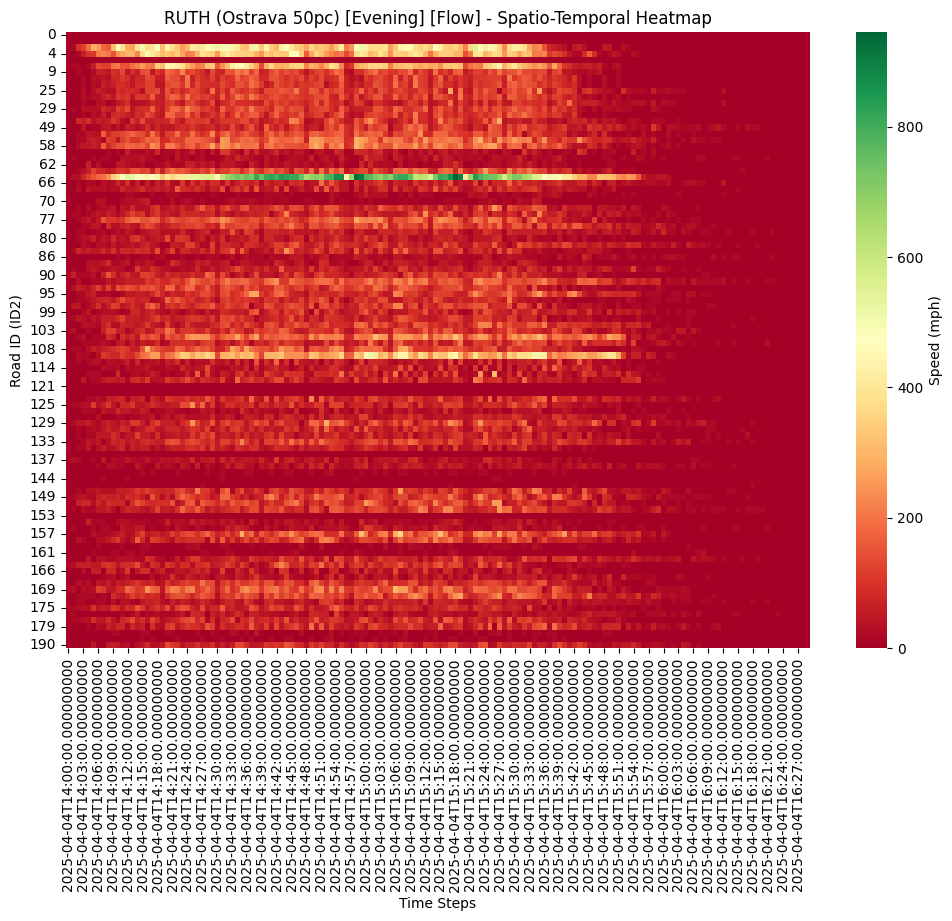

In [45]:
plot_heatmap(df_ruth_evening_flow * 15, "RUTH (Ostrava 50pc) [Evening] [Flow]")

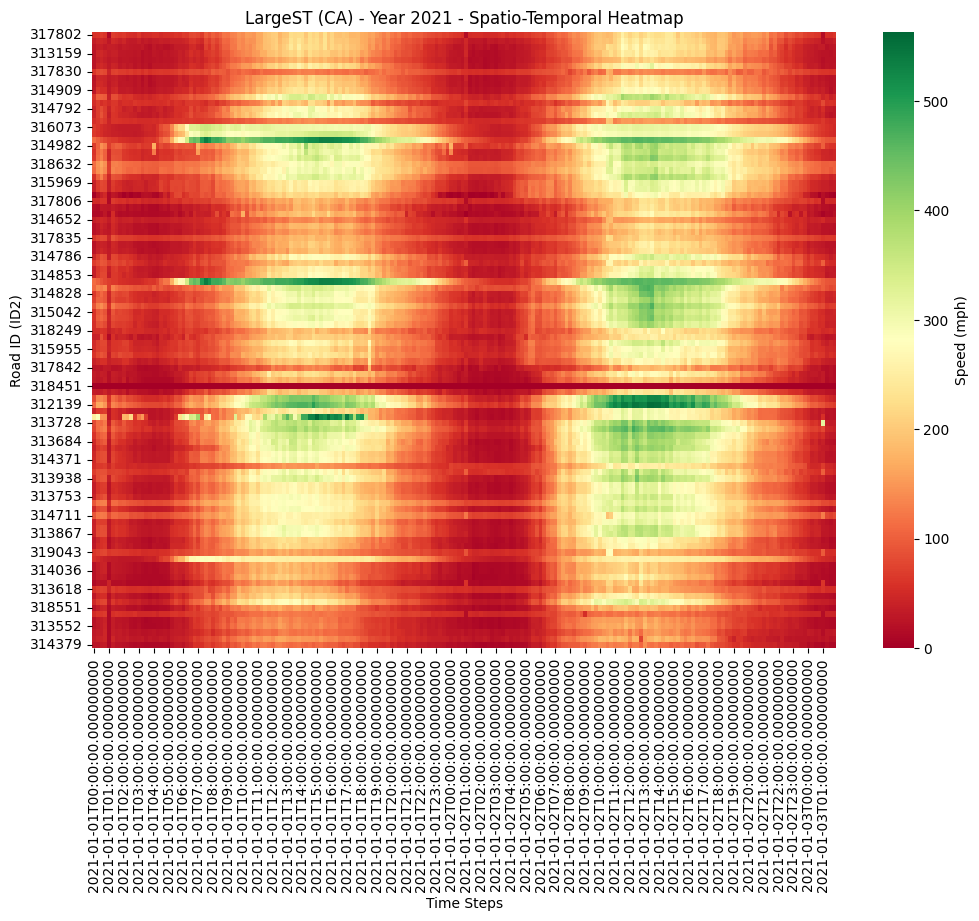

In [7]:
plot_heatmap(df_largest, "LargeST (CA) - Year 2021")